# model_experiment_Prophet

Prophet (Taylor & Letham, Facebook 2017) — an additive (GAM-style) model per series:

`y(t) = trend(t) + seasonality(t) + holidays(t) + noise`

- **trend** — piecewise-linear with automatically detected changepoints;
- **seasonality** — Fourier series (yearly here; weekly/daily off for weekly data);
- **holidays** — explicit regressors for our big-4 holiday weeks, Prophet's distinctive advantage over ARIMA-family models.

Unlike SARIMA (~3.5s/series at s=52), Prophet's MAP fit takes ~0.3s/series, so we fit it on **every series with ≥60 weeks of history** (~2900 series, ~17 min) instead of a top-50 hybrid — still per-series (no cross-series learning), which remains the family's structural limitation.

MLflow experiment: **Prophet_Training**. CPU; full Run All ≈ 40 min.

In [1]:
# Kaggle bootstrap — does nothing when running locally.
import os
ON_KAGGLE = os.path.exists("/kaggle")
if ON_KAGGLE:
    os.system("pip install -q mlflow prophet")
    if not os.path.exists("walmart-sales-forecasting"):
        os.system("git clone https://github.com/ekatsirekidze/walmart-sales-forecasting.git")
    import sys; sys.path.insert(0, "/kaggle/working/walmart-sales-forecasting")
    import glob, shutil, zipfile
    src = glob.glob("/kaggle/input/*walmart*") + glob.glob("/kaggle/input/*/*walmart*")
    assert src, "competition data not attached"
    os.makedirs("data", exist_ok=True)
    for f in glob.glob(src[0] + "/*"):
        (zipfile.ZipFile(f).extractall("data") if f.endswith(".zip") else shutil.copy(f, "data"))
    from kaggle_secrets import UserSecretsClient
    s = UserSecretsClient()
    os.environ["MLFLOW_TRACKING_URI"] = s.get_secret("MLFLOW_TRACKING_URI")
    os.environ["MLFLOW_TRACKING_USERNAME"] = s.get_secret("MLFLOW_TRACKING_USERNAME")
    os.environ["MLFLOW_TRACKING_PASSWORD"] = s.get_secret("MLFLOW_TRACKING_PASSWORD")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 634.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 72.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.6/954.6 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.9/214.9 kB 10.7 MB/s eta 0:00:00


Cloning into 'walmart-sales-forecasting'...


In [2]:
import sys, pathlib, time, logging
sys.path.insert(0, str(pathlib.Path().resolve()))
logging.getLogger("cmdstanpy").disabled = True   # else 2 log lines per fit x 3000 fits

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from prophet import Prophet

from src.data import load_raw, make_submission
from src.metrics import wmae_report
from src.validation import split_fold
from src.mlflow_utils import setup_mlflow
from src.postprocess import naive_lag52, apply_christmas_shift, blend_holiday_naive
from src.preprocessing import (SUPER_BOWL, LABOR_DAY, THANKSGIVING, CHRISTMAS,
                               BLEND_HOLIDAY_WEEKS)

train, test, features, stores = load_raw("data" if ON_KAGGLE else None)
setup_mlflow("Prophet_Training")

HOLIDAYS = pd.concat([
    pd.DataFrame({"holiday": "super_bowl", "ds": SUPER_BOWL}),
    pd.DataFrame({"holiday": "labor_day", "ds": LABOR_DAY}),
    pd.DataFrame({"holiday": "thanksgiving", "ds": THANKSGIVING}),
    pd.DataFrame({"holiday": "christmas", "ds": CHRISTMAS}),
])


def prophet_forecast_all(history, target_dates, min_obs=60):
    """Fit Prophet per series (>= min_obs observations), return long pred df."""
    future = pd.DataFrame({"ds": pd.DatetimeIndex(target_dates)})
    counts = history.groupby(["Store", "Dept"]).size()
    eligible = counts[counts >= min_obs].index
    rows = []
    t0 = time.time()
    for k, (st, dp) in enumerate(eligible):
        y = history[(history.Store == st) & (history.Dept == dp)][
            ["Date", "Weekly_Sales"]].rename(columns={"Date": "ds", "Weekly_Sales": "y"})
        try:
            m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                        daily_seasonality=False, holidays=HOLIDAYS)
            m.fit(y)
            fc = m.predict(future)
            rows.append(pd.DataFrame({"Store": st, "Dept": dp,
                                      "Date": fc["ds"], "pred": fc["yhat"]}))
        except Exception:
            pass
        if (k + 1) % 500 == 0:
            print(f"  {k+1}/{len(eligible)} series ({time.time()-t0:.0f}s)")
    print(f"fitted {len(rows)}/{len(eligible)} series in {(time.time()-t0)/60:.1f} min")
    return pd.concat(rows)


def assemble(pred_long, history, target):
    m = target.merge(pred_long, on=["Store", "Dept", "Date"], how="left")
    coverage = m["pred"].notna().mean()
    m["pred"] = m["pred"].fillna(pd.Series(naive_lag52(history, target), index=m.index))
    dep_med = history.groupby("Dept")["Weekly_Sales"].median()
    m["pred"] = m["pred"].fillna(m["Dept"].map(dep_med)).fillna(0)
    return m, coverage

2026/07/11 14:25:30 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Training' does not exist. Creating a new experiment.


MLflow -> https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow | experiment: Prophet_Training


## Run 1 — Anatomy of one fit: components plot (Store 20 / Dept 92)

14:25:31 - cmdstanpy - INFO - Chain [1] start processing
14:25:31 - cmdstanpy - INFO - Chain [1] done processing


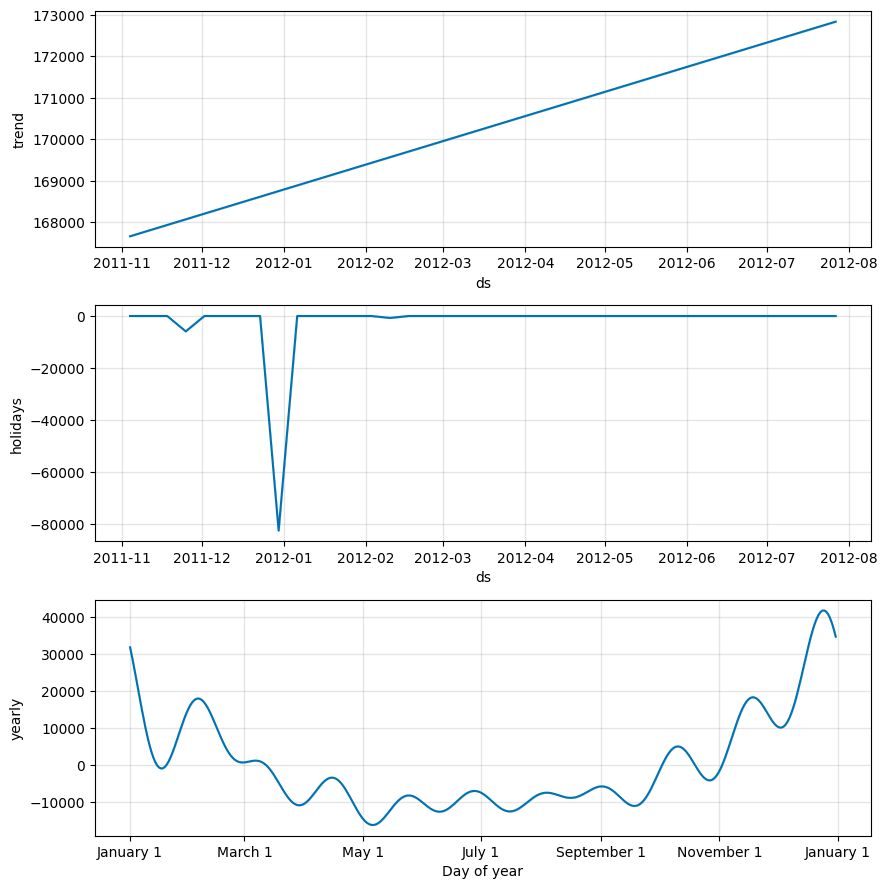

🏃 View run Prophet_Demo at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/dda6ce24b4f64791ba3a7d6bae8887f4
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7


In [3]:
tr, va = split_fold(train, 1)
s = tr[(tr.Store == 20) & (tr.Dept == 92)][["Date", "Weekly_Sales"]].rename(
    columns={"Date": "ds", "Weekly_Sales": "y"})
m_demo = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                 daily_seasonality=False, holidays=HOLIDAYS)
m_demo.fit(s)
fc_demo = m_demo.predict(pd.DataFrame({"ds": sorted(va["Date"].unique())}))
m_demo.plot_components(fc_demo)
plt.show()

with mlflow.start_run(run_name="Prophet_Demo"):
    mlflow.log_params({"series": "store20_dept92",
                       "components": "piecewise trend + yearly Fourier + 4 holiday regressors"})

## Run 2 — Fold-1 evaluation: Prophet on ALL eligible series (~17 min)

In [4]:
pred_va = prophet_forecast_all(tr, sorted(va["Date"].unique()))
m1, coverage = assemble(pred_va, tr, va)
rep = wmae_report(m1["Weekly_Sales"], m1["pred"], m1["IsHoliday"])
with mlflow.start_run(run_name="Prophet_CV_Fold1"):
    mlflow.log_params({"min_obs": 60, "holidays": "big-4 regressors",
                       "fallback": "seasonal naive + dept median", "fold": 1})
    mlflow.log_metrics({**rep, "coverage": coverage})
print(f"coverage {coverage:.3f}, {rep}")

14:25:33 - cmdstanpy - INFO - Chain [1] start processing
14:25:34 - cmdstanpy - INFO - Chain [1] done processing
14:25:34 - cmdstanpy - INFO - Chain [1] start processing
14:25:34 - cmdstanpy - INFO - Chain [1] done processing
14:25:34 - cmdstanpy - INFO - Chain [1] start processing
14:25:34 - cmdstanpy - INFO - Chain [1] done processing
14:25:34 - cmdstanpy - INFO - Chain [1] start processing
14:25:34 - cmdstanpy - INFO - Chain [1] done processing
14:25:34 - cmdstanpy - INFO - Chain [1] start processing
14:25:35 - cmdstanpy - INFO - Chain [1] done processing
14:25:35 - cmdstanpy - INFO - Chain [1] start processing
14:25:35 - cmdstanpy - INFO - Chain [1] done processing
14:25:35 - cmdstanpy - INFO - Chain [1] start processing
14:25:35 - cmdstanpy - INFO - Chain [1] done processing
14:25:35 - cmdstanpy - INFO - Chain [1] start processing
14:25:36 - cmdstanpy - INFO - Chain [1] done processing
14:25:36 - cmdstanpy - INFO - Chain [1] start processing
14:25:36 - cmdstanpy - INFO - Chain [1]

  500/2886 series (171s)


14:28:24 - cmdstanpy - INFO - Chain [1] done processing
14:28:25 - cmdstanpy - INFO - Chain [1] start processing
14:28:25 - cmdstanpy - INFO - Chain [1] done processing
14:28:25 - cmdstanpy - INFO - Chain [1] start processing
14:28:25 - cmdstanpy - INFO - Chain [1] done processing
14:28:25 - cmdstanpy - INFO - Chain [1] start processing
14:28:25 - cmdstanpy - INFO - Chain [1] done processing
14:28:26 - cmdstanpy - INFO - Chain [1] start processing
14:28:26 - cmdstanpy - INFO - Chain [1] done processing
14:28:26 - cmdstanpy - INFO - Chain [1] start processing
14:28:27 - cmdstanpy - INFO - Chain [1] done processing
14:28:27 - cmdstanpy - INFO - Chain [1] start processing
14:28:27 - cmdstanpy - INFO - Chain [1] done processing
14:28:27 - cmdstanpy - INFO - Chain [1] start processing
14:28:27 - cmdstanpy - INFO - Chain [1] done processing
14:28:27 - cmdstanpy - INFO - Chain [1] start processing
14:28:27 - cmdstanpy - INFO - Chain [1] done processing
14:28:27 - cmdstanpy - INFO - Chain [1] 

  1000/2886 series (340s)


14:31:13 - cmdstanpy - INFO - Chain [1] start processing
14:31:13 - cmdstanpy - INFO - Chain [1] done processing
14:31:13 - cmdstanpy - INFO - Chain [1] start processing
14:31:14 - cmdstanpy - INFO - Chain [1] done processing
14:31:14 - cmdstanpy - INFO - Chain [1] start processing
14:31:14 - cmdstanpy - INFO - Chain [1] done processing
14:31:14 - cmdstanpy - INFO - Chain [1] start processing
14:31:14 - cmdstanpy - INFO - Chain [1] done processing
14:31:14 - cmdstanpy - INFO - Chain [1] start processing
14:31:15 - cmdstanpy - INFO - Chain [1] done processing
14:31:15 - cmdstanpy - INFO - Chain [1] start processing
14:31:15 - cmdstanpy - INFO - Chain [1] done processing
14:31:15 - cmdstanpy - INFO - Chain [1] start processing
14:31:15 - cmdstanpy - INFO - Chain [1] done processing
14:31:15 - cmdstanpy - INFO - Chain [1] start processing
14:31:16 - cmdstanpy - INFO - Chain [1] done processing
14:31:16 - cmdstanpy - INFO - Chain [1] start processing
14:31:16 - cmdstanpy - INFO - Chain [1]

...

  2000/2886 series (668s)


14:36:42 - cmdstanpy - INFO - Chain [1] done processing
14:36:42 - cmdstanpy - INFO - Chain [1] start processing
14:36:42 - cmdstanpy - INFO - Chain [1] done processing
14:36:42 - cmdstanpy - INFO - Chain [1] start processing
14:36:42 - cmdstanpy - INFO - Chain [1] done processing
14:36:42 - cmdstanpy - INFO - Chain [1] start processing
14:36:43 - cmdstanpy - INFO - Chain [1] done processing
14:36:43 - cmdstanpy - INFO - Chain [1] start processing
14:36:43 - cmdstanpy - INFO - Chain [1] done processing
14:36:43 - cmdstanpy - INFO - Chain [1] start processing
14:36:44 - cmdstanpy - INFO - Chain [1] done processing
14:36:44 - cmdstanpy - INFO - Chain [1] start processing
14:36:44 - cmdstanpy - INFO - Chain [1] done processing
14:36:44 - cmdstanpy - INFO - Chain [1] start processing
14:36:44 - cmdstanpy - INFO - Chain [1] done processing
14:36:44 - cmdstanpy - INFO - Chain [1] start processing
14:36:45 - cmdstanpy - INFO - Chain [1] done processing
14:36:45 - cmdstanpy - INFO - Chain [1] 

  2500/2886 series (833s)


14:39:26 - cmdstanpy - INFO - Chain [1] done processing
14:39:27 - cmdstanpy - INFO - Chain [1] start processing
14:39:27 - cmdstanpy - INFO - Chain [1] done processing
14:39:27 - cmdstanpy - INFO - Chain [1] start processing
14:39:27 - cmdstanpy - INFO - Chain [1] done processing
14:39:27 - cmdstanpy - INFO - Chain [1] start processing
14:39:28 - cmdstanpy - INFO - Chain [1] done processing
14:39:28 - cmdstanpy - INFO - Chain [1] start processing
14:39:28 - cmdstanpy - INFO - Chain [1] done processing
14:39:28 - cmdstanpy - INFO - Chain [1] start processing
14:39:29 - cmdstanpy - INFO - Chain [1] done processing
14:39:29 - cmdstanpy - INFO - Chain [1] start processing
14:39:29 - cmdstanpy - INFO - Chain [1] done processing
14:39:29 - cmdstanpy - INFO - Chain [1] start processing
14:39:29 - cmdstanpy - INFO - Chain [1] done processing
14:39:29 - cmdstanpy - INFO - Chain [1] start processing
14:39:30 - cmdstanpy - INFO - Chain [1] done processing
14:39:30 - cmdstanpy - INFO - Chain [1] 

fitted 2886/2886 series in 16.0 min
🏃 View run Prophet_CV_Fold1 at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/24304e35a5704175a384bfa902031b1e
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7
coverage 0.959, {'wmae': 2180.939233127506, 'mae_holiday': 2248.398809279546, 'mae_nonholiday': 2152.444569838192}


## Run 3 — Holiday blend check

In [5]:
blend_scores = {}
for w in (0.0, 0.25, 0.5):
    blended = blend_holiday_naive(m1[["Store", "Dept", "Date", "pred"]], tr,
                                  weight=w, holiday_dates=BLEND_HOLIDAY_WEEKS)
    r = wmae_report(m1["Weekly_Sales"], blended["pred"], m1["IsHoliday"])
    blend_scores[w] = r["wmae"]
    with mlflow.start_run(run_name=f"Prophet_Blend_noXmas_w{w}"):
        mlflow.log_params({"blend_weight": w, "fold": 1})
        mlflow.log_metrics(r)
    print(f"w={w}: {r}")
BLEND_W = min(blend_scores, key=blend_scores.get)
print("best blend weight:", BLEND_W)

🏃 View run Prophet_Blend_noXmas_w0.0 at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/d9d9ae052a6346669e52bce9203a9e86
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7
w=0.0: {'wmae': 2180.939233127506, 'mae_holiday': 2248.398809279546, 'mae_nonholiday': 2152.444569838192}
🏃 View run Prophet_Blend_noXmas_w0.25 at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/e9f4047fb9444ea78a00c772c09cacd9
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7
w=0.25: {'wmae': 2162.3132008397374, 'mae_holiday': 2185.6766516658017, 'mae_nonholiday': 2152.444569838192}
🏃 View run Prophet_Blend_noXmas_w0.5 at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/d8df9e65afcf48a5957bd3f4aea1261a
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow

## Run 4 — Final: full train -> test submission (~20 min)

In [6]:
pred_test = prophet_forecast_all(train, sorted(test["Date"].unique()))
sub, coverage = assemble(pred_test, train, test[["Store", "Dept", "Date"]])
sub = sub[["Store", "Dept", "Date", "pred"]]
sub = apply_christmas_shift(sub, pred_col="pred")
if BLEND_W > 0:
    sub = blend_holiday_naive(sub, train, weight=BLEND_W, holiday_dates=BLEND_HOLIDAY_WEEKS)

with mlflow.start_run(run_name="Prophet_Final"):
    mlflow.log_params({"min_obs": 60, "blend_weight": BLEND_W,
                       "post": "christmas_shift + noXmas_blend"})
    mlflow.log_metrics({"fold1_wmae": rep["wmae"], "test_coverage": coverage})

make_submission(sub, "pred", "submission_prophet.csv")
print(f"wrote submission_prophet.csv (coverage {coverage:.3f}, blend w={BLEND_W})")

14:41:41 - cmdstanpy - INFO - Chain [1] start processing
14:41:41 - cmdstanpy - INFO - Chain [1] done processing
14:41:41 - cmdstanpy - INFO - Chain [1] start processing
14:41:41 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1] done processing
14:41:42 - cmdstanpy - INFO - Chain [1] start processing
14:41:42 - cmdstanpy - INFO - Chain [1]

  500/2971 series (46s)


14:42:27 - cmdstanpy - INFO - Chain [1] start processing
14:42:27 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1] done processing
14:42:28 - cmdstanpy - INFO - Chain [1] start processing
14:42:28 - cmdstanpy - INFO - Chain [1]

  1000/2971 series (93s)


14:43:14 - cmdstanpy - INFO - Chain [1] done processing
14:43:14 - cmdstanpy - INFO - Chain [1] start processing
14:43:14 - cmdstanpy - INFO - Chain [1] done processing
14:43:14 - cmdstanpy - INFO - Chain [1] start processing
14:43:14 - cmdstanpy - INFO - Chain [1] done processing
14:43:14 - cmdstanpy - INFO - Chain [1] start processing
14:43:14 - cmdstanpy - INFO - Chain [1] done processing
14:43:14 - cmdstanpy - INFO - Chain [1] start processing
14:43:14 - cmdstanpy - INFO - Chain [1] done processing
14:43:15 - cmdstanpy - INFO - Chain [1] start processing
14:43:15 - cmdstanpy - INFO - Chain [1] done processing
14:43:15 - cmdstanpy - INFO - Chain [1] start processing
14:43:15 - cmdstanpy - INFO - Chain [1] done processing
14:43:15 - cmdstanpy - INFO - Chain [1] start processing
14:43:15 - cmdstanpy - INFO - Chain [1] done processing
14:43:15 - cmdstanpy - INFO - Chain [1] start processing
14:43:15 - cmdstanpy - INFO - Chain [1] done processing
14:43:15 - cmdstanpy - INFO - Chain [1] 

...

  2000/2971 series (187s)


14:44:48 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1] done processing
14:44:49 - cmdstanpy - INFO - Chain [1] start processing
14:44:49 - cmdstanpy - INFO - Chain [1]

  2500/2971 series (236s)


14:45:37 - cmdstanpy - INFO - Chain [1] done processing
14:45:37 - cmdstanpy - INFO - Chain [1] start processing
14:45:37 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:38 - cmdstanpy - INFO - Chain [1] start processing
14:45:38 - cmdstanpy - INFO - Chain [1] done processing
14:45:39 - cmdstanpy - INFO - Chain [1] 

fitted 2971/2971 series in 4.7 min
🏃 View run Prophet_Final at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7/runs/d6daa88607b342ceb88d0c6e318cb149
🧪 View experiment at: https://dagshub.com/ekatsirekidze/walmart-sales-forecasting.mlflow/#/experiments/7
wrote submission_prophet.csv (coverage 0.980, blend w=0.5)
